In [ ]:
!pip install mediapipe opencv-python-headless pandas openpyxl neurokit2 scikit-learn matplotlib wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 13.6 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas=

**Importación de Librerias**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
import urllib.request
import os
import wfdb
print("Librerias importadas")

Librerias importadas


**Importar la señal**

Columnas disponibles: ['Time [s]', ' RESP', ' PLETH', ' V', ' AVR', ' II']
Señal OBTENIDA
Señal procesada


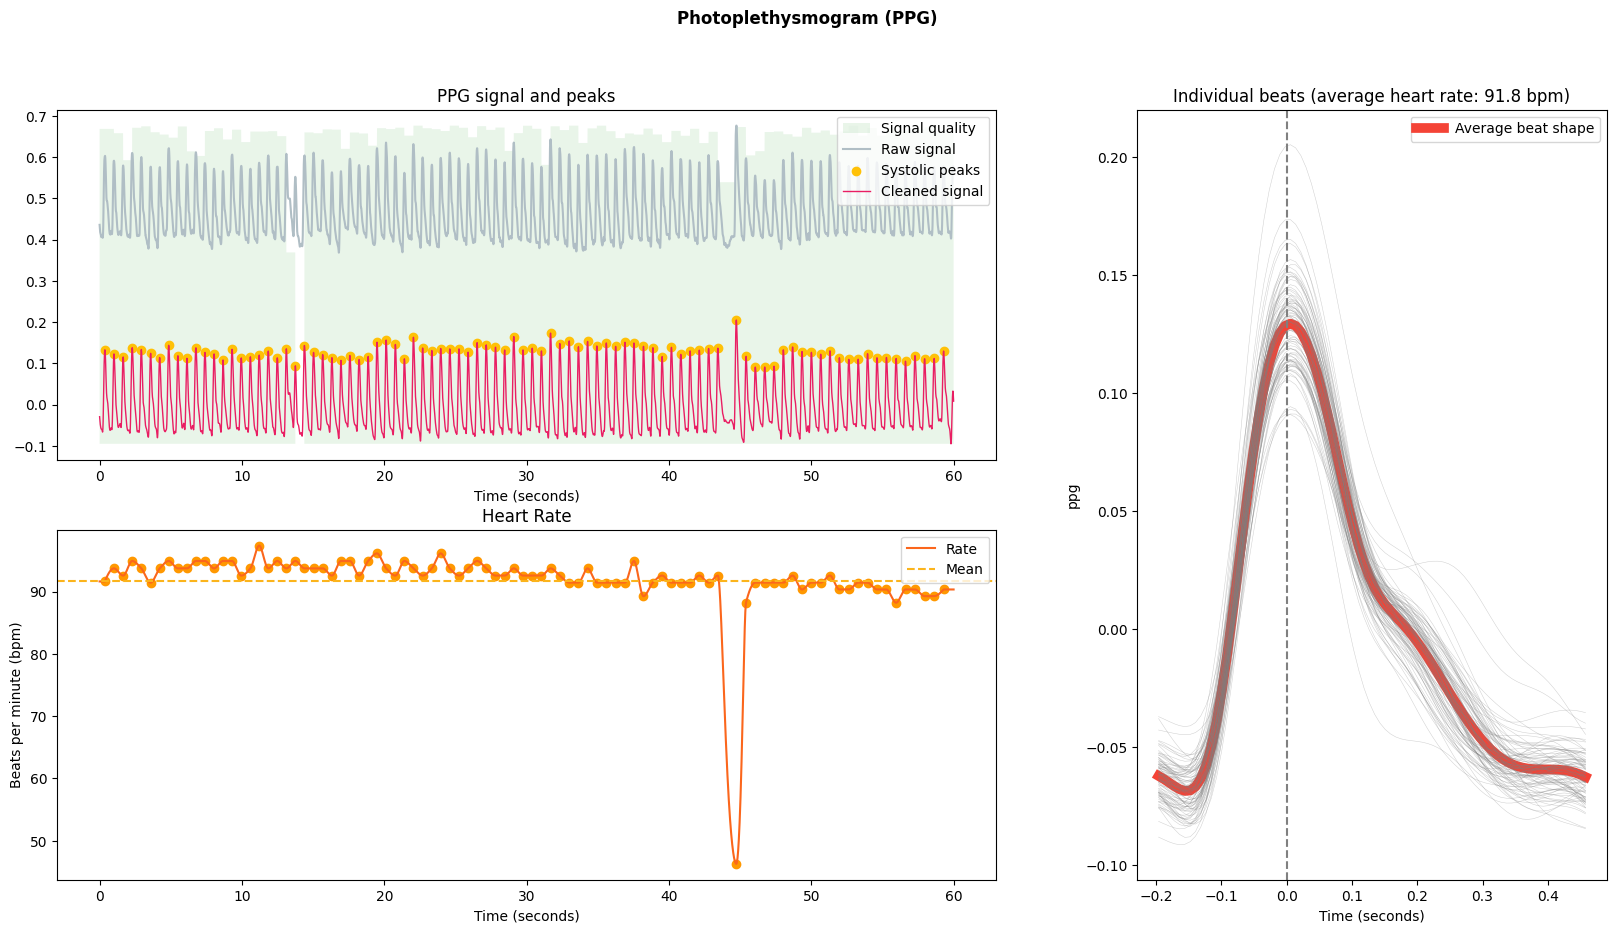

In [ ]:
df_paciente = pd.read_csv('bidmc_01_Signals.csv')
print("Columnas disponibles:", df_paciente.columns.tolist())

# Extraemos la señal
senal_ppg_p1 = df_paciente[' PLETH'] #Recuerden que aquí debe estar el espacio antes de PLETH
frec_muestreo = 125
print("Señal OBTENIDA")

# Tomamos solo los primeros 60 segundos
senal_corta_p1 = senal_ppg_p1[:60 * int(frec_muestreo)]
senal_procesada_p1, picos_info_p1 = nk.ppg_process(senal_corta_p1, sampling_rate=frec_muestreo)
print("Señal procesada")

# Visualizar la señal
nk.ppg_plot(senal_procesada_p1, info=picos_info_p1)
fig = plt.gcf()
fig.set_size_inches(20, 10)
plt.show()

**Extracción de Biomarcadores**

In [ ]:
import scipy.signal
import numpy as np

# HRV (Sistema Nervioso Autonomo)
df_hrv = nk.hrv(picos_info_p1, sampling_rate=frec_muestreo, show=False)
media_hrv = df_hrv['HRV_MeanNN'].values[0]
desviacion_hrv = df_hrv['HRV_SDNN'].values[0]

# Tiempo Promedio de Subida Sistólica
senal_limpia = senal_procesada_p1["PPG_Clean"].values
picos = picos_info_p1['PPG_Peaks']

valles, _ = scipy.signal.find_peaks(-senal_limpia) #Como para PPG no existe delineate hay que invertir la señal para que los 0 sean maximos

tiempos_subida = []

for pico in picos:
    if np.isnan(pico):
        continue
    valles_anteriores = valles[valles < pico]
    if len(valles_anteriores) > 0:
        # El inicio del latido es el último valle que ocurrió antes del pico
        inicio = valles_anteriores[-1]
        tiempo_segundos = (pico - inicio) / frec_muestreo
        tiempos_subida.append(tiempo_segundos)
df_hrv['Morf_Tiempo_Subida_Seg'] = np.mean(tiempos_subida)


print("\nHRV Media: ", media_hrv)
print("HRV Desviacion: ", desviacion_hrv)
print("Tiempo Promedio de Subida Sistólica: ", df_hrv['Morf_Tiempo_Subida_Seg'].values[0])


HRV Media:  654.6666666666666
HRV Desviacion:  69.51776104797676
Tiempo Promedio de Subida Sistólica:  0.15824175824175823


/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
